# 19. MK1 vs 언어모델 하나: 학습을 똑같이 시켜도 이길까?

이 프로젝트 가설은 "작은 부품을 잘 엮은 MK1이 LLM 하나보다 낫다"야. 상대는 노트북에 있는 **LFM2.5-1.2B**.

- **1라운드 (학습 없는 LFM)**: LFM은 그냥 그대로 시험 봄. 근데 MK1 부품은 이 문제들로 학습했으니까 불공평해.
- **2라운드 (같은 데이터로 학습한 LFM)**: 그래서 LFM도 MK1 부품들이 배운 데이터로 LoRA 학습시켜서 다시 붙였어.

시험은 두 가지야. 우리가 만든 세계 3종(600문제씩), 그리고 외부 시험 **KorQuAD 1.0**(한국어 읽기, 한 번만 봄).
채점: 맞으면 **+1**, "모름"이면 **0**, 틀리면 **−1** (답이 진짜 모름인 문제에서 모름이라고 하면 +1).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
from cognitive_lab import summary_versus as S
from cognitive_lab import viz as V
V.setup()
signed = FuncFormatter(lambda v, _: f"{v:+.2f}" if abs(v) > 1e-9 else "0")  # ASCII minus: Malgun Gothic has no U+2212
COLORS = {"mk1": V.BLUE, "llm": V.NEUTRAL, "llm-mk1-versus-lora": V.ORANGE}
LABELS = dict(S.SYSTEMS)
vs = S.versus_scores()
train = S.lora_training()
for k, t in train.items():
    print(k, "LoRA:", t["trainable_parameters"], "개 학습 |", [h["validation"] for h in t["history"]], "검증 (전→후) |",
          round(t["seconds"] / 60), "분 | GPU", t["peak_gpu_gb"], "GB")

klue LoRA: 5554176 개 학습 | [0.3726, 0.5765] 검증 (전→후) | 77 분 | GPU 2.78 GB
versus LoRA: 5554176 개 학습 | [-0.8809, -0.6447] 검증 (전→후) | 48 분 | GPU 4.02 GB


## 1. 우리 세계 3종: 순점수

막대 끝 선은 95% 구간(부트스트랩, 기사·문 세계는 40문제 세션 단위로 다시 뽑음).
회색 빗금 막대는 결과 파일에 문제별 기록이 없어서 설계 노트 표 숫자를 그대로 쓴 거야 (구간 없음).
LFM은 답 방식 3개 중 **가장 좋은 걸** 골라 줬어. LFM에 유리한 쪽이야.

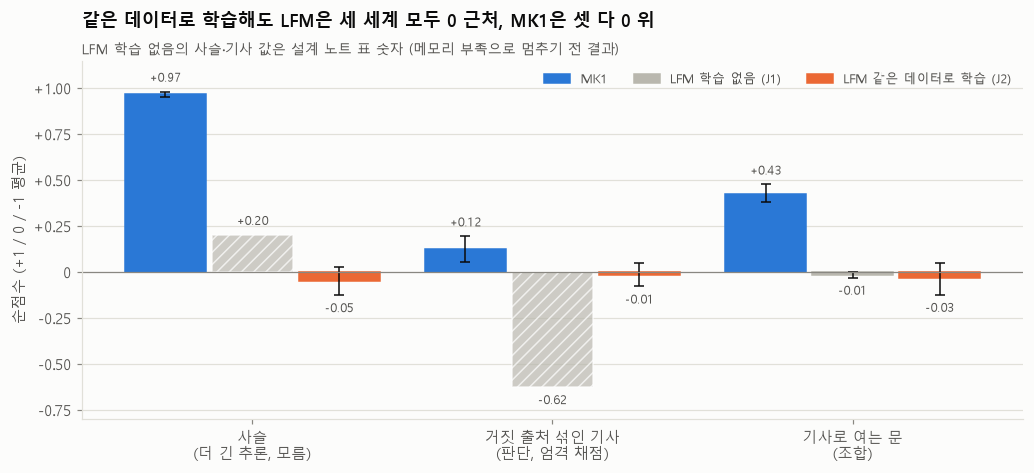

In [2]:
fams = S.FAMILIES
x = np.arange(len(fams)); w = 0.27
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for i, (key, label) in enumerate(S.SYSTEMS):
    for xi, (f, _) in enumerate(fams):
        e = vs[f].get(key)
        if e is None:
            continue
        pos = xi + (i - 1) * (w + 0.02)
        noted = e["lo"] is None
        ax.bar(pos, e["score"], width=w, color=COLORS[key], hatch="///" if noted else None,
               edgecolor="white" if noted else COLORS[key], alpha=0.7 if noted else 1, label=label if xi == 2 else None)
        if not noted:
            ax.errorbar(pos, e["score"], yerr=[[e["score"] - e["lo"]], [e["hi"] - e["score"]]], color=V.TEXT, lw=1, capsize=3)
        top = e["hi"] if not noted else e["score"]
        bot = e["lo"] if not noted else e["score"]
        y = top + 0.04 if e["score"] >= 0 else bot - 0.04
        ax.text(pos, y, f"{e['score']:+.2f}", ha="center", va="bottom" if e["score"] >= 0 else "top",
                fontsize=8, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, [l for _, l in fams]); ax.grid(axis="x", visible=False)
ax.set_ylim(-0.8, 1.15); ax.yaxis.set_major_locator(MultipleLocator(0.25)); ax.yaxis.set_major_formatter(signed); ax.set_ylabel("순점수 (+1 / 0 / -1 평균)")
ax.legend(fontsize=8.5, loc="upper right", ncol=3, bbox_to_anchor=(1, 1.0))
ax.set_title("같은 데이터로 학습해도 LFM은 세 세계 모두 0 근처, MK1은 셋 다 0 위", pad=22)
V.note(ax, "LFM 학습 없음의 사슬·기사 값은 설계 노트 표 숫자 (메모리 부족으로 멈추기 전 결과)")
fig.tight_layout(); plt.show()

## 2. 왜 그럴까: 맞힌 비율 vs 틀린 비율

순점수 = 맞음 − 틀림이야. 위로 맞힌 비율, 아래로 틀린 비율. 나머지는 "모름"이라고 멈춘 거.
학습한 LFM은 **맞히는 건 많이 늘었는데**, 모를 때도 답해서 틀림이 절반쯤이야.

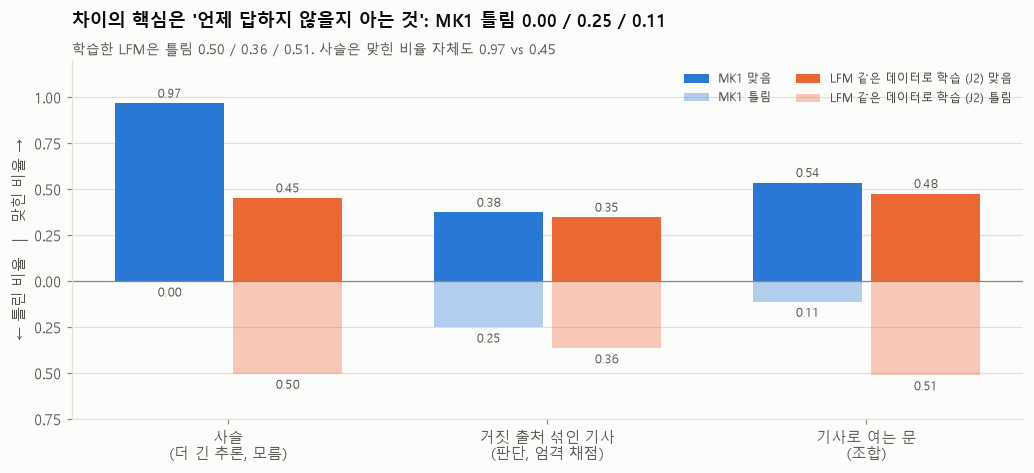

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
shown = [("mk1", "MK1"), ("llm-mk1-versus-lora", "LFM 같은 데이터로 학습 (J2)")]
w = 0.34
for i, (key, label) in enumerate(shown):
    for xi, (f, _) in enumerate(fams):
        e = vs[f][key]
        pos = xi + (i - 0.5) * (w + 0.03)
        ax.bar(pos, e["right"], width=w, color=COLORS[key], label=f"{label} 맞음" if xi == 0 else None)
        ax.bar(pos, -e["wrong"], width=w, color=COLORS[key], alpha=0.35, label=f"{label} 틀림" if xi == 0 else None)
        ax.text(pos, e["right"] + 0.03, f"{e['right']:.2f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
        ax.text(pos, -e["wrong"] - 0.03, f"{e['wrong']:.2f}", ha="center", va="top", fontsize=8, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, [l for _, l in fams]); ax.grid(axis="x", visible=False)
ax.set_ylim(-0.75, 1.2); ax.yaxis.set_major_locator(MultipleLocator(0.25)); ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{abs(v):.2f}"))
ax.set_ylabel("← 틀린 비율   |   맞힌 비율 →")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.set_title("차이의 핵심은 '언제 답하지 않을지 아는 것': MK1 틀림 0.00 / 0.25 / 0.11", pad=22)
V.note(ax, "학습한 LFM은 틀림 0.50 / 0.36 / 0.51. 사슬은 맞힌 비율 자체도 0.97 vs 0.45")
fig.tight_layout(); plt.show()

## 3. 같은 문제끼리 짝지어 본 차이 (MK1 − LFM)

두 시스템이 똑같은 600문제를 같은 순서로 풀었으니까, 문제별로 빼서 차이를 봤어. 0보다 확실히 크면 MK1이 이긴 거야.
학습 없는 LFM은 문제별 기록이 문 세계에만 남아서 거기만 있어.

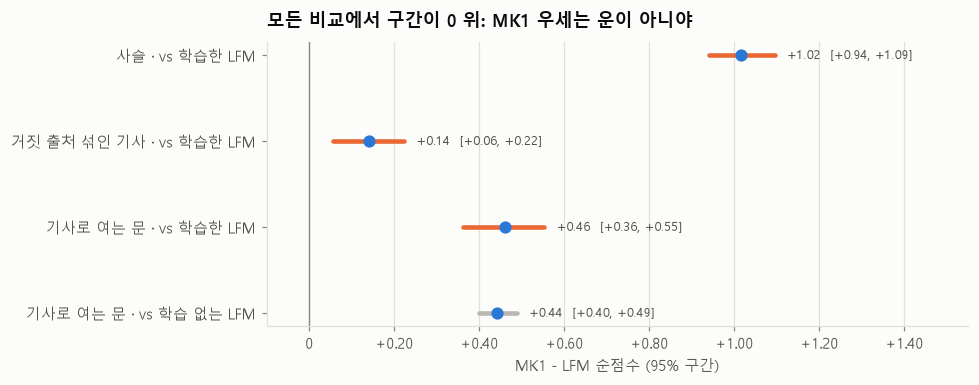

In [4]:
gap2 = S.paired_gap(vs, "llm-mk1-versus-lora")
gap1 = S.paired_gap(vs, "llm")
fig, ax = plt.subplots(figsize=(9, 3.6))
rows = [(f"{lbl.splitlines()[0]} · vs 학습한 LFM", gap2[f], V.ORANGE) for f, lbl in fams] +        [(f"{lbl.splitlines()[0]} · vs 학습 없는 LFM", gap1[f], V.NEUTRAL) for f, lbl in fams if f in gap1]
for yi, (lbl, (m, lo, hi), col) in enumerate(rows):
    ax.plot([lo, hi], [yi, yi], color=col, lw=3, solid_capstyle="round")
    ax.plot(m, yi, "o", color=V.BLUE, ms=7)
    ax.text(hi + 0.03, yi, f"{m:+.2f}  [{lo:+.2f}, {hi:+.2f}]", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.axvline(0, color=V.MUTED, lw=0.9)
ax.set_yticks(range(len(rows)), [r[0] for r in rows]); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlim(-0.1, 1.55); ax.xaxis.set_major_locator(MultipleLocator(0.2)); ax.xaxis.set_major_formatter(signed); ax.set_xlabel("MK1 - LFM 순점수 (95% 구간)")
ax.set_title("모든 비교에서 구간이 0 위: MK1 우세는 운이 아니야", pad=10)
fig.tight_layout(); plt.show()

## 4. 외부 시험 KorQuAD 1.0 (한국어 읽기, 5,774문제)

KorQuAD로는 아무것도 학습·조정 안 했고, 시험지는 한 번만 열었어. 여기서는 저장된 답만 다시 채점해서 구간을 냈어 (문제 단위 부트스트랩).
- **정확 일치(EM)**: 답이 글자 그대로 같아야 맞음.
- **글자 F1**: 글자가 얼마나 겹치는지 (부분 점수).

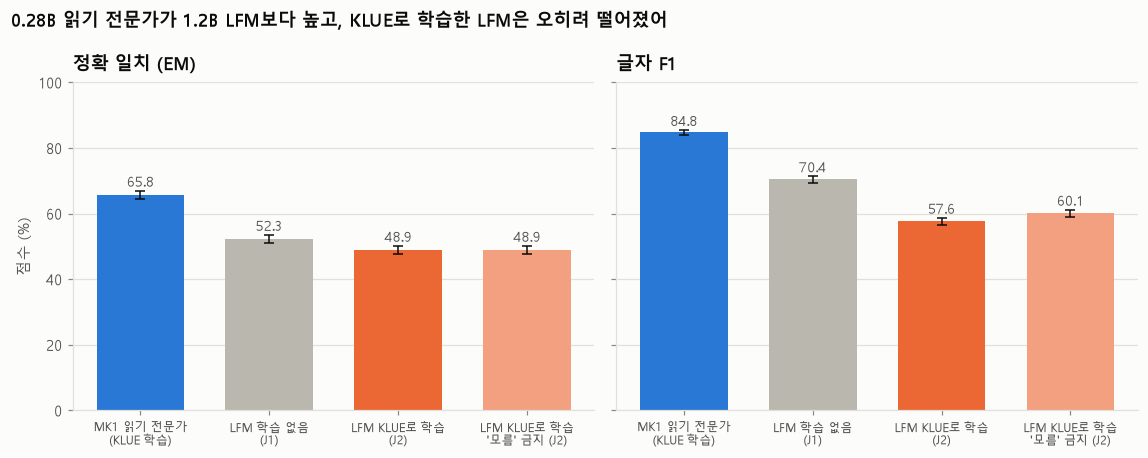

In [5]:
kq = S.korquad_rows()
ci = S.korquad_ci(kq)
names = [n for n, _, _ in S.KORQUAD]
kcol = {"mk1": V.BLUE, "llm": V.NEUTRAL, "llm-mk1-klue-lora": V.ORANGE, "llm-mk1-klue-lora-no-unknown": "#f2a07f"}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, metric, title in zip(axes, ("em", "f1"), ("정확 일치 (EM)", "글자 F1")):
    for i, n in enumerate(names):
        m, lo, hi = ci[n][metric]
        ax.bar(i, m, color=kcol[n], width=0.68)
        ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], color=V.TEXT, lw=1, capsize=3)
        ax.text(i, hi + 1.2, f"{m:.1f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
    ax.set_xticks(range(len(names)), [l for _, l, _ in S.KORQUAD], fontsize=8)
    ax.grid(axis="x", visible=False); ax.set_ylim(0, 100); ax.set_title(title, pad=8)
axes[0].set_ylabel("점수 (%)")
fig.suptitle("0.28B 읽기 전문가가 1.2B LFM보다 높고, KLUE로 학습한 LFM은 오히려 떨어졌어",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()

## 5. 학습한 LFM은 왜 떨어졌나: "모름" 남발

KLUE에는 "답 없음" 문제가 31% 있어. LFM이 그걸 배워서, 답이 다 있는 KorQuAD에서도 **30%를 "모름"**이라고 했어.
그래서 학습한 LFM이 모름이라고 한 문제 / 답을 쓴 문제로 나눠 봤어.

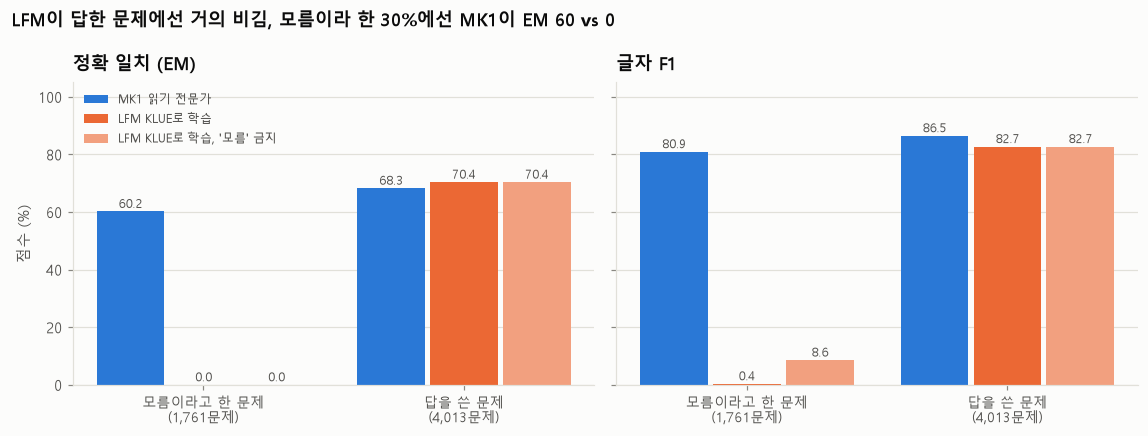

학습한 LFM의 모름 비율: 30.5%
모름을 막으면 '모르름', '모르는', '모르지 않음' 같은 변형을 써서 그 문제들에서 EM 0 (설계 노트)


In [6]:
sp = S.korquad_unknown_split(kq)
show = [("mk1", "MK1 읽기 전문가"), ("llm-mk1-klue-lora", "LFM KLUE로 학습"), ("llm-mk1-klue-lora-no-unknown", "LFM KLUE로 학습, '모름' 금지")]
groups = list(sp["groups"])
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
w = 0.26
for ax, metric, title in zip(axes, ("em", "f1"), ("정확 일치 (EM)", "글자 F1")):
    for i, (n, label) in enumerate(show):
        for gi, g in enumerate(groups):
            v = sp["groups"][g][n][metric]
            pos = gi + (i - 1) * (w + 0.02)
            ax.bar(pos, v, width=w, color=kcol[n], label=label if gi == 0 else None)
            ax.text(pos, v + 1.2, f"{v:.1f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
    ax.set_xticks(range(len(groups)), [f"{g}\n({sp['n'][g]:,}문제)" for g in groups], fontsize=9)
    ax.grid(axis="x", visible=False); ax.set_ylim(0, 105); ax.set_title(title, pad=8)
axes[0].set_ylabel("점수 (%)"); axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("LFM이 답한 문제에선 거의 비김, 모름이라 한 30%에선 MK1이 EM 60 vs 0",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()
print(f"학습한 LFM의 모름 비율: {sp['share_unknown']:.1%}")
print("모름을 막으면 '모르름', '모르는', '모르지 않음' 같은 변형을 써서 그 문제들에서 EM 0 (설계 노트)")

'답을 쓴 문제'(4,013개)는 LFM이 스스로 고른 문제라 아마 쉬운 쪽이야. 그래서 "거기서 비긴다"를 너무 크게 보면 안 돼.

## 6. 크기와 속도

같은 읽기 시험을 풀 때 크기와 처리 속도야 (KorQuAD 기준).

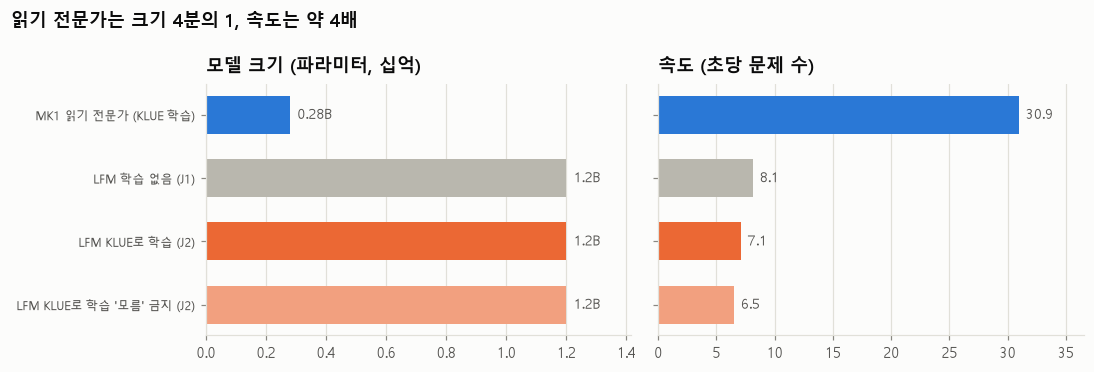

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, vals, unit, title in ((axes[0], [s for _, _, s in S.KORQUAD], "B", "모델 크기 (파라미터, 십억)"),
                              (axes[1], [kq[n]["qps"] for n in names], "", "속도 (초당 문제 수)")):
    for i, (n, v) in enumerate(zip(names, vals)):
        ax.barh(i, v, color=kcol[n], height=0.6)
        ax.text(v + max(vals) * 0.02, i, f"{v:g}{unit}" if unit else f"{v:.1f}", va="center", fontsize=9, color=V.TEXT_SECONDARY)
    ax.set_yticks(range(len(names)), [l.replace(chr(10), " ") for _, l, _ in S.KORQUAD], fontsize=8)
    ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, max(vals) * 1.18); ax.set_title(title, pad=8)
axes[1].set_yticklabels([])
fig.suptitle("읽기 전문가는 크기 4분의 1, 속도는 약 4배", x=0.01, ha="left", fontsize=12, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()

## 7. 정리 (설계 노트 결론 그대로)

- **1라운드 (학습 없는 LFM)**: MK1이 크게 이겼어. 근데 이건 "학습한 전문가 조합 > 학습 안 한 범용 모델"까지만 말해 줘.
- **읽기 하나 (KorQuAD)**: 1라운드의 큰 차이(F1 84.8 vs 70.4)는 대부분 "학습했냐 안 했냐"였어. 같은 데이터로 학습하면 답하는 문제에선 비슷해. 대신 **처음 보는 데이터셋으로 넘어갈 때** 0.28B 전문가가 더 안정적이야(모름 남발 없음). 크기는 4분의 1, 속도는 4배.
- **조합이 필요한 문제 (우리 세계 3종)**: 같은 데이터로 학습해도 MK1이 1.2B LLM보다 크게 나아. 특히 **모르면 멈추기**와 **여러 단계 추론(사슬)**에서.
- **남은 한계**
  - 학습량이 똑같진 않아. LFM은 노트북 시간 때문에 4,000문제 1에포크만 학습했고, MK1 부품들은 더 많이 봤어(기사 신뢰 부품은 8만 문제).
  - 사슬은 학습량 차이가 크지 않은데도 차이가 커서, 학습량만으로 설명되진 않아.
  - 우리가 만든 세계라는 한계가 남아. 외부 시험에서 "조합"을 보이는 건 다음 단계 몫이야 (`design/agi-blueprint-2026-10-09.md`).